In [1]:
import os, random, time
from collections import Counter, defaultdict
from pathlib import Path
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Sampler
from torchvision import transforms, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score, accuracy_score, precision_recall_fscore_support

In [2]:
DATA_DIR = "/kaggle/input/blood-cell-cancer-all-4class/Blood cell Cancer [ALL]"   # <<-- Change this to your dataset folder
IMG_SIZE = 224
BATCH_SIZE = 32
LR = 1e-5
RANDOM_SEED = 42
TARGET_PER_CLASS = None   # None => balance to max class count; or set integer (e.g., 979) to match paper
NUM_WORKERS = 2
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

Device: cuda


In [3]:
class_names = sorted([d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, d))])
print("Detected classes:", class_names)
image_paths, image_labels = [], []
for idx, cls in enumerate(class_names):
    cls_dir = os.path.join(DATA_DIR, cls)
    for fn in os.listdir(cls_dir):
        if fn.lower().endswith(('.png','jpg','jpeg','bmp','tif','tiff')):
            image_paths.append(os.path.join(cls_dir, fn))
            image_labels.append(idx)
image_paths = np.array(image_paths)
image_labels = np.array(image_labels)
print("Found images:", len(image_paths))
print("Original distribution:", Counter(image_labels))

Detected classes: ['Benign', '[Malignant] Pre-B', '[Malignant] Pro-B', '[Malignant] early Pre-B']
Found images: 3242
Original distribution: Counter({3: 979, 1: 955, 2: 796, 0: 512})


In [4]:
Benign_path = "/kaggle/input/blood-cell-cancer-all-4class/Blood cell Cancer [ALL]/Benign"
malignant_pre_B_path = "/kaggle/input/blood-cell-cancer-all-4class/Blood cell Cancer [ALL]/[Malignant] Pre-B"
malignant_pro_B_path = "/kaggle/input/blood-cell-cancer-all-4class/Blood cell Cancer [ALL]/[Malignant] Pro-B"
malignant_early_pre_B_path = "/kaggle/input/blood-cell-cancer-all-4class/Blood cell Cancer [ALL]/[Malignant] early Pre-B"

# **Benign**

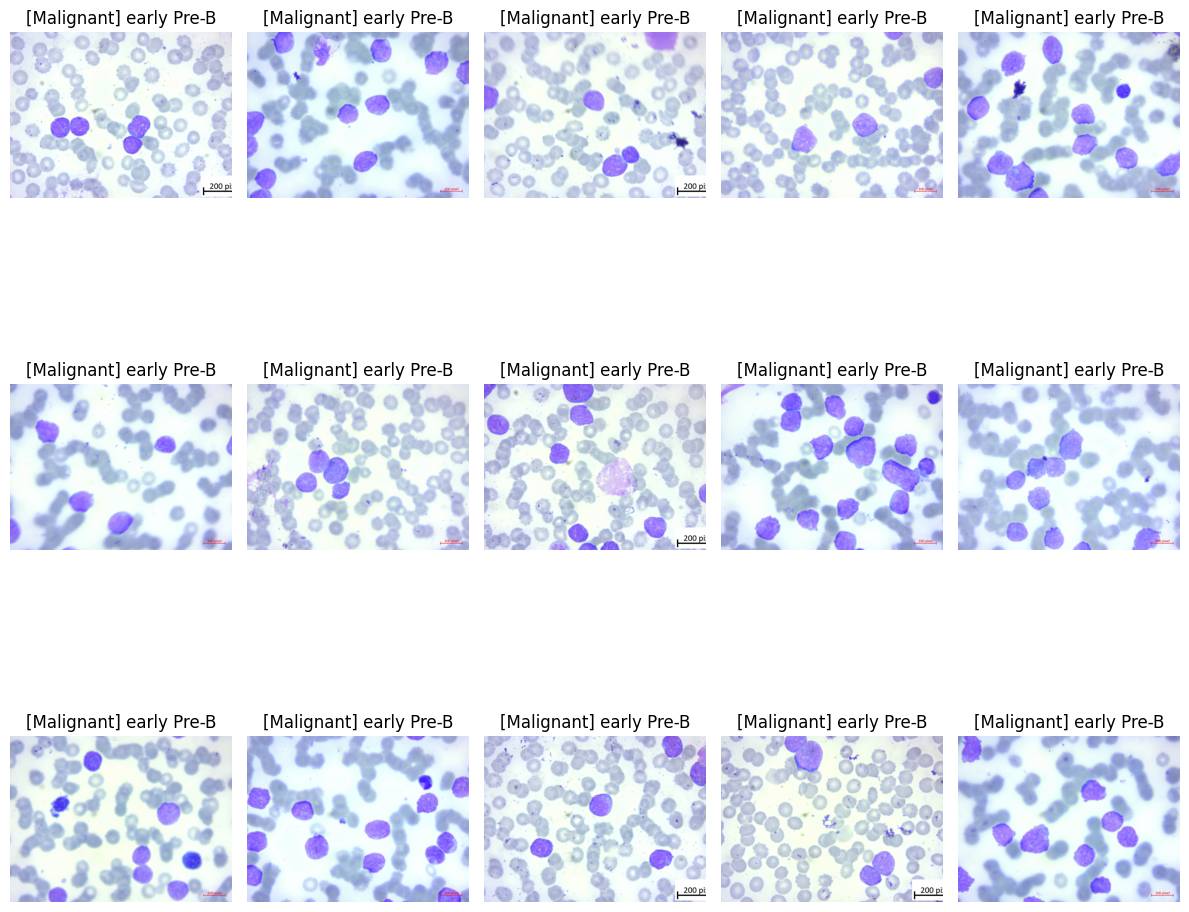

In [5]:
def plot_sample_images(data_dir, num_imgs=15):
    """
    Plots sample images from all subfolders of the dataset directory.
    """
    # Get subdirectories (classes)
    class_dirs = [os.path.join(data_dir, cls) for cls in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, cls))]
    
    # Collect images from all classes
    img_paths = []
    for cls_dir in class_dirs:
        cls_files = [os.path.join(cls_dir, f) for f in os.listdir(cls_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        img_paths.extend(cls_files)
    
    # Limit to num_imgs
    img_paths = img_paths[:num_imgs]
    
    # Plot images
    plt.figure(figsize=(12,12))
    cols = 5
    rows = int(np.ceil(len(img_paths)/cols))
    
    for idx, img_path in enumerate(img_paths):
        plt.subplot(rows, cols, idx+1)
        img = plt.imread(img_path)
        plt.imshow(img)
        plt.axis('off')
        plt.title(os.path.basename(os.path.dirname(img_path)))  # show class name
    
    plt.tight_layout()
    plt.show()

# ---------------- Call the function ----------------
plot_sample_images(DATA_DIR, num_imgs=15)

# **malignant-pre-B**

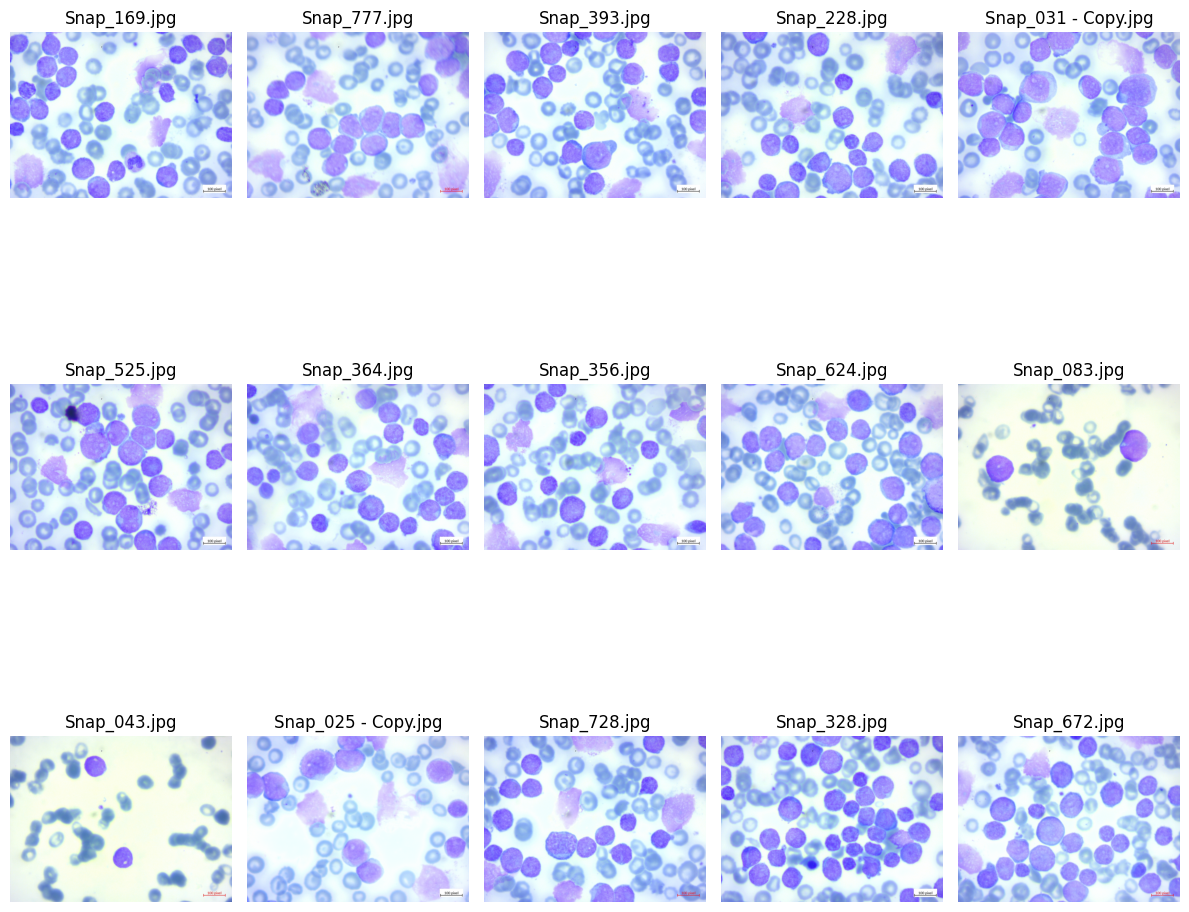

In [6]:
def plot_imgs(item_dir, num_imgs=15):
    """
    Plots sample images from a specific folder.
    """
    all_item_files = [f for f in os.listdir(item_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    item_files = [os.path.join(item_dir, f) for f in all_item_files][:num_imgs]

    plt.figure(figsize=(12,12))
    cols = 5
    rows = int(np.ceil(len(item_files)/cols))

    for idx, img_path in enumerate(item_files):
        plt.subplot(rows, cols, idx+1)
        img = plt.imread(img_path)
        plt.imshow(img)
        plt.axis('off')
        plt.title(os.path.basename(img_path))  # optional: show filename

    plt.tight_layout()
    plt.show()

# Example usage:
# Replace `malignant_pre_B_path` with your folder path
plot_imgs(malignant_pre_B_path, num_imgs=15)


# **malignant-pro-B**

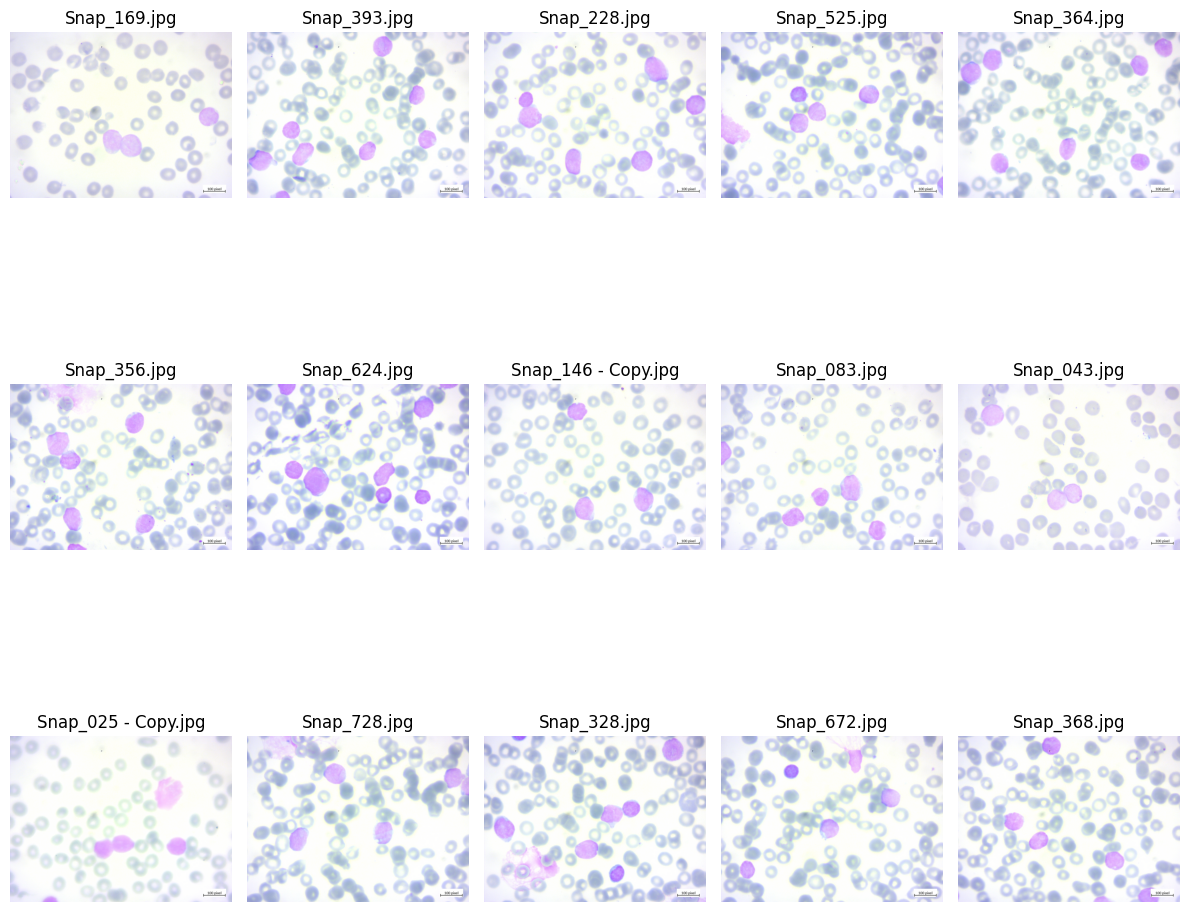

In [7]:
plot_imgs(malignant_pro_B_path,num_imgs=15)

# **malignant-early-pre-B**

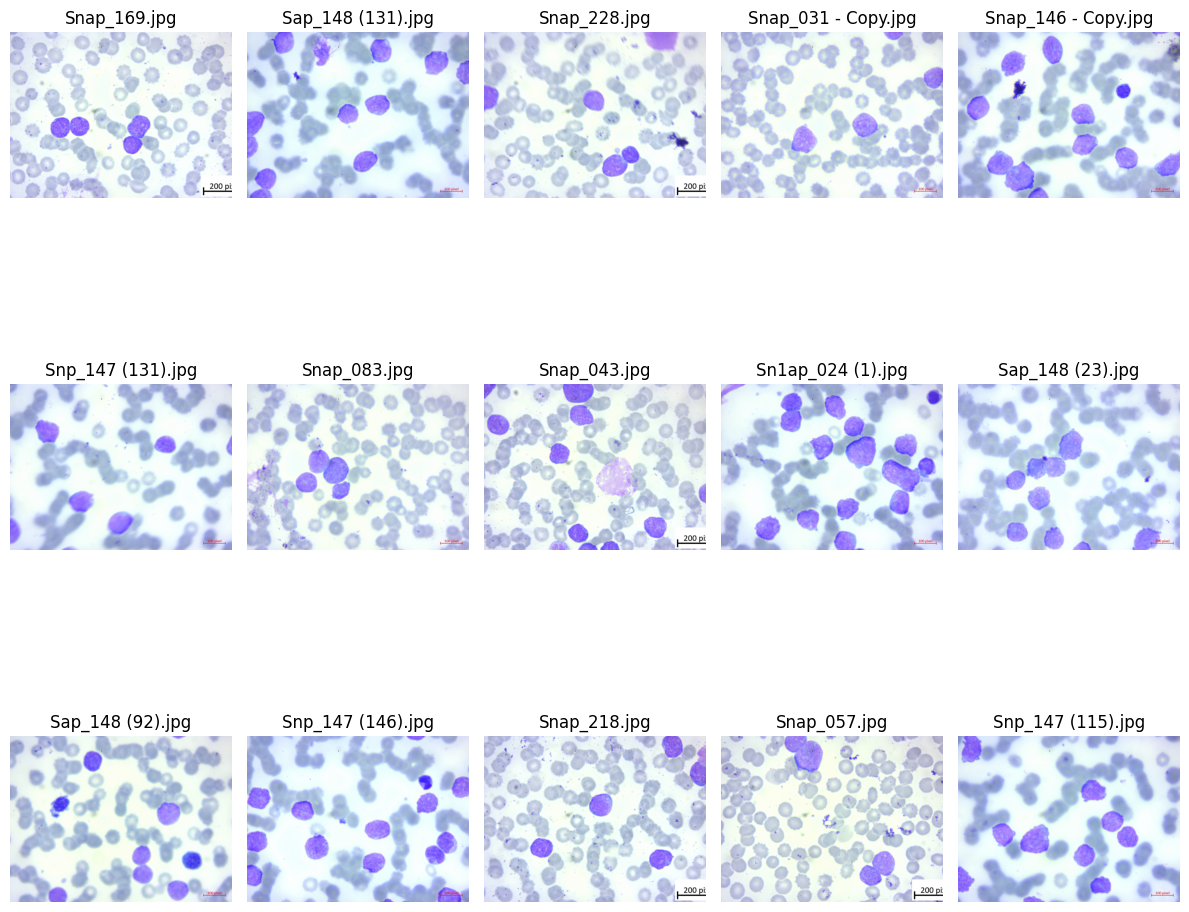

In [8]:
plot_imgs(malignant_early_pre_B_path,num_imgs=15)

# Create  EfficientNet-B0

In [9]:
import torch
import torch.nn as nn
from torchvision import models

class EfficientNetB0Model(nn.Module):
    def __init__(self, num_classes=len(class_names), freeze_backbone=True):
        super().__init__()
        # Load pretrained EfficientNet-B0
        efficientnet = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
        
        # Extract features (all layers except classifier)
        self.features = efficientnet.features
        self.avgpool = efficientnet.avgpool
        
        # Freeze backbone if needed
        if freeze_backbone:
            for p in self.features.parameters():
                p.requires_grad = False
        
        # Custom classifier
        # EfficientNet-B0 outputs 1280 features
        self.classifier = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(1280, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )
    
    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

# Create model instance
model_efficientnet = EfficientNetB0Model(num_classes=len(class_names), freeze_backbone=True).to(DEVICE)
print("=" * 60)
print("EfficientNet-B0 Model Created")
print("=" * 60)

# Optimizer and Scheduler
criterion_eff = nn.CrossEntropyLoss()
optimizer_eff = torch.optim.Adam(filter(lambda p: p.requires_grad, model_efficientnet.parameters()), lr=LR)
scheduler_eff = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_eff, mode='max', factor=0.5, patience=3, verbose=True
)


EfficientNet-B0 Model Created


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


# MobileNetV3-Large

In [10]:
class MobileNetV3Model(nn.Module):
    def __init__(self, num_classes=len(class_names), freeze_backbone=True):
        super().__init__()
        # Load pretrained MobileNetV3-Large
        mobilenet = models.mobilenet_v3_large(weights=models.MobileNet_V3_Large_Weights.IMAGENET1K_V1)
        
        # Extract features
        self.features = mobilenet.features
        self.avgpool = mobilenet.avgpool
        
        # Freeze backbone if needed
        if freeze_backbone:
            for p in self.features.parameters():
                p.requires_grad = False
        
        # Custom classifier
        # MobileNetV3-Large outputs 960 features
        self.classifier = nn.Sequential(
            nn.Linear(960, 512),
            nn.Hardswish(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(512, num_classes)
        )
    
    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

# Create model instance
model_mobilenet = MobileNetV3Model(num_classes=len(class_names), freeze_backbone=True).to(DEVICE)
print("=" * 60)
print("MobileNetV3-Large Model Created")
print("=" * 60)

# Optimizer and Scheduler
criterion_mob = nn.CrossEntropyLoss()
optimizer_mob = torch.optim.Adam(filter(lambda p: p.requires_grad, model_mobilenet.parameters()), lr=LR)
scheduler_mob = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_mob, mode='max', factor=0.5, patience=3, verbose=True
)


MobileNetV3-Large Model Created


# DenseNet121

In [11]:
class DenseNet121Model(nn.Module):
    def __init__(self, num_classes=len(class_names), freeze_backbone=True):
        super().__init__()
        # Load pretrained DenseNet121
        densenet = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
        
        # Extract features
        self.features = densenet.features
        self.relu = nn.ReLU(inplace=True)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        
        # Freeze backbone if needed
        if freeze_backbone:
            for p in self.features.parameters():
                p.requires_grad = False
        
        # Custom classifier
        # DenseNet121 outputs 1024 features
        self.classifier = nn.Sequential(
            nn.Linear(1024, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(512, num_classes)
        )
    
    def forward(self, x):
        features = self.features(x)
        out = self.relu(features)
        out = self.avgpool(out)
        out = torch.flatten(out, 1)
        out = self.classifier(out)
        return out

# Create model instance
model_densenet = DenseNet121Model(num_classes=len(class_names), freeze_backbone=True).to(DEVICE)
print("=" * 60)
print("DenseNet121 Model Created")
print("=" * 60)

# Optimizer and Scheduler
criterion_dense = nn.CrossEntropyLoss()
optimizer_dense = torch.optim.Adam(filter(lambda p: p.requires_grad, model_densenet.parameters()), lr=LR)
scheduler_dense = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_dense, mode='max', factor=0.5, patience=3, verbose=True
)

DenseNet121 Model Created


# Training Function these Three

In [12]:
def train_one_epoch_single(model, loader, optimizer, criterion):
    """Train function for single model"""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for imgs, lbls in loader:
        imgs = imgs.to(DEVICE, dtype=torch.float)
        lbls = lbls.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, lbls)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == lbls).sum().item()
        total += imgs.size(0)
    return running_loss/total, correct/total

def eval_model_single(model, loader, criterion):
    """Evaluation function for single model"""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    all_probs = []
    with torch.no_grad():
        for imgs, lbls in loader:
            imgs = imgs.to(DEVICE, dtype=torch.float)
            lbls = lbls.to(DEVICE)
            outputs = model(imgs)
            loss = criterion(outputs, lbls)
            probs = F.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)
            running_loss += loss.item() * imgs.size(0)
            correct += (preds == lbls).sum().item()
            total += imgs.size(0)
            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(lbls.cpu().tolist())
            all_probs.extend(probs.cpu().numpy())
    avg_loss = running_loss/total
    acc = correct/total
    return avg_loss, acc, np.array(all_preds), np.array(all_labels), np.array(all_probs)


# Data Balanace

In [13]:
NUM_EPOCHS = 10

In [14]:
counts = Counter(image_labels)
if TARGET_PER_CLASS is None:
    target_count = max(counts.values())
else:
    target_count = TARGET_PER_CLASS
print("Balancing target per class:", target_count)

Balancing target per class: 979


In [15]:
balanced_paths = []
balanced_labels = []
for cls in range(len(class_names)):
    idxs = np.where(image_labels == cls)[0].tolist()
    if len(idxs) == 0:
        continue
    # replicate randomly to reach target_count
    times = target_count // len(idxs)
    rem = target_count % len(idxs)
    chosen = idxs * times + random.sample(idxs, rem)
    balanced_paths += [image_paths[i] for i in chosen]
    balanced_labels += [cls] * len(chosen)

balanced_paths = np.array(balanced_paths)
balanced_labels = np.array(balanced_labels)
print("Balanced dataset size:", len(balanced_paths), Counter(balanced_labels))

Balanced dataset size: 3916 Counter({0: 979, 1: 979, 2: 979, 3: 979})


In [16]:
class BloodDataset(Dataset):
    def __init__(self, paths, labels, indices, transform):
        self.paths = paths[indices]
        self.labels = labels[indices]
        self.transform = transform
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        p = self.paths[idx]
        img = Image.open(p).convert("L")  # grayscale
        if self.transform:
            img = self.transform(img)
        label = int(self.labels[idx])
        return img, label

In [17]:
train_idx, temp_idx = train_test_split(np.arange(len(balanced_labels)),
                                       test_size=0.30, 
                                       stratify=balanced_labels, 
                                       random_state=RANDOM_SEED)

val_idx, test_idx = train_test_split(temp_idx, 
                                     test_size=0.50, 
                                     stratify=balanced_labels[temp_idx], 
                                     random_state=RANDOM_SEED)

print("Split -> train:", len(train_idx), 
      "val:", len(val_idx), 
      "test:", len(test_idx))

Split -> train: 2741 val: 587 test: 588


In [18]:
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(15),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.85,1.0)),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5], [0.5,0.5,0.5])
])
val_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5], [0.5,0.5,0.5])
])


In [19]:
train_ds = BloodDataset(balanced_paths, 
                        balanced_labels, 
                        train_idx, 
                        train_transform)
val_ds   = BloodDataset(balanced_paths, 
                        balanced_labels, 
                        val_idx, 
                        val_transform)
test_ds  = BloodDataset(balanced_paths, 
                        balanced_labels, 
                        test_idx, 
                        val_transform)


In [20]:
train_loader = DataLoader(train_ds, 
                          batch_size=BATCH_SIZE,
                          shuffle=True, 
                          num_workers=NUM_WORKERS, 
                          pin_memory=True)
val_loader   = DataLoader(val_ds, 
                          batch_size=BATCH_SIZE, 
                          shuffle=False, 
                          num_workers=NUM_WORKERS, 
                          pin_memory=True)
test_loader  = DataLoader(test_ds, 
                          batch_size=BATCH_SIZE, 
                          shuffle=False, 
                          num_workers=NUM_WORKERS, 
                          pin_memory=True)

# EfficientNet-B0 LOOP

In [21]:
print("\n" + "=" * 60)
print("TRAINING EfficientNet-B0")
print("=" * 60)

best_val_acc_eff = 0.0
history_eff = {"train_loss":[], "val_loss":[], "train_acc":[], "val_acc":[]}
start_time = time.time()

for epoch in range(1, NUM_EPOCHS+1):
    t0 = time.time()
    train_loss, train_acc = train_one_epoch_single(model_efficientnet, train_loader, optimizer_eff, criterion_eff)
    val_loss, val_acc, _, _, _ = eval_model_single(model_efficientnet, val_loader, criterion_eff)
    
    history_eff["train_loss"].append(train_loss)
    history_eff["val_loss"].append(val_loss)
    history_eff["train_acc"].append(train_acc)
    history_eff["val_acc"].append(val_acc)
    
    scheduler_eff.step(val_acc)
    
    if val_acc > best_val_acc_eff:
        best_val_acc_eff = val_acc
        torch.save(model_efficientnet.state_dict(), "best_efficientnet_model.pth")
        print(f"✓ Epoch {epoch}: saved best model with val_acc={val_acc:.4f}")
    
    print(f"Epoch {epoch}/{NUM_EPOCHS} | train_loss={train_loss:.4f}, train_acc={train_acc:.4f} | val_loss={val_loss:.4f}, val_acc={val_acc:.4f} | time={time.time()-t0:.1f}s")

print(f"Training done in {round((time.time()-start_time)/60,2)} minutes. Best val acc: {best_val_acc_eff:.4f}")



TRAINING EfficientNet-B0
✓ Epoch 1: saved best model with val_acc=0.4804
Epoch 1/10 | train_loss=1.3446, train_acc=0.3645 | val_loss=1.3143, val_acc=0.4804 | time=40.3s
✓ Epoch 2: saved best model with val_acc=0.6593
Epoch 2/10 | train_loss=1.2751, train_acc=0.5553 | val_loss=1.2399, val_acc=0.6593 | time=38.7s
✓ Epoch 3: saved best model with val_acc=0.7513
Epoch 3/10 | train_loss=1.2034, train_acc=0.6516 | val_loss=1.1657, val_acc=0.7513 | time=39.2s
✓ Epoch 4: saved best model with val_acc=0.7734
Epoch 4/10 | train_loss=1.1312, train_acc=0.7264 | val_loss=1.0896, val_acc=0.7734 | time=38.6s
✓ Epoch 5: saved best model with val_acc=0.8177
Epoch 5/10 | train_loss=1.0539, train_acc=0.7767 | val_loss=1.0079, val_acc=0.8177 | time=38.4s
✓ Epoch 6: saved best model with val_acc=0.8348
Epoch 6/10 | train_loss=0.9718, train_acc=0.8045 | val_loss=0.9273, val_acc=0.8348 | time=39.3s
✓ Epoch 7: saved best model with val_acc=0.8603
Epoch 7/10 | train_loss=0.9044, train_acc=0.8340 | val_loss=0.

# MobileNetV3-Large LOOP

In [22]:
print("\n" + "=" * 60)
print("TRAINING MobileNetV3-Large")
print("=" * 60)

best_val_acc_mob = 0.0
history_mob = {"train_loss":[], "val_loss":[], "train_acc":[], "val_acc":[]}
start_time = time.time()

for epoch in range(1, NUM_EPOCHS+1):
    t0 = time.time()
    train_loss, train_acc = train_one_epoch_single(model_mobilenet, train_loader, optimizer_mob, criterion_mob)
    val_loss, val_acc, _, _, _ = eval_model_single(model_mobilenet, val_loader, criterion_mob)
    
    history_mob["train_loss"].append(train_loss)
    history_mob["val_loss"].append(val_loss)
    history_mob["train_acc"].append(train_acc)
    history_mob["val_acc"].append(val_acc)
    
    scheduler_mob.step(val_acc)
    
    if val_acc > best_val_acc_mob:
        best_val_acc_mob = val_acc
        torch.save(model_mobilenet.state_dict(), "best_mobilenet_model.pth")
        print(f"✓ Epoch {epoch}: saved best model with val_acc={val_acc:.4f}")
    
    print(f"Epoch {epoch}/{NUM_EPOCHS} | train_loss={train_loss:.4f}, train_acc={train_acc:.4f} | val_loss={val_loss:.4f}, val_acc={val_acc:.4f} | time={time.time()-t0:.1f}s")

print(f"Training done in {round((time.time()-start_time)/60,2)} minutes. Best val acc: {best_val_acc_mob:.4f}")



TRAINING MobileNetV3-Large
✓ Epoch 1: saved best model with val_acc=0.4906
Epoch 1/10 | train_loss=1.3078, train_acc=0.5115 | val_loss=1.3164, val_acc=0.4906 | time=39.5s
✓ Epoch 2: saved best model with val_acc=0.7036
Epoch 2/10 | train_loss=1.1701, train_acc=0.7621 | val_loss=1.2071, val_acc=0.7036 | time=38.9s
Epoch 3/10 | train_loss=1.0431, train_acc=0.8355 | val_loss=1.1467, val_acc=0.6934 | time=38.3s
✓ Epoch 4: saved best model with val_acc=0.7104
Epoch 4/10 | train_loss=0.9308, train_acc=0.8617 | val_loss=1.0941, val_acc=0.7104 | time=37.7s
✓ Epoch 5: saved best model with val_acc=0.7462
Epoch 5/10 | train_loss=0.8284, train_acc=0.8920 | val_loss=1.0287, val_acc=0.7462 | time=37.6s
✓ Epoch 6: saved best model with val_acc=0.7785
Epoch 6/10 | train_loss=0.7477, train_acc=0.8986 | val_loss=0.9389, val_acc=0.7785 | time=37.8s
✓ Epoch 7: saved best model with val_acc=0.8416
Epoch 7/10 | train_loss=0.6690, train_acc=0.8862 | val_loss=0.8021, val_acc=0.8416 | time=37.3s
✓ Epoch 8: s

# LOOP - DenseNet121

In [23]:
print("\n" + "=" * 60)
print("TRAINING DenseNet121")
print("=" * 60)

best_val_acc_dense = 0.0
history_dense = {"train_loss":[], "val_loss":[], "train_acc":[], "val_acc":[]}
start_time = time.time()

for epoch in range(1, NUM_EPOCHS+1):
    t0 = time.time()
    train_loss, train_acc = train_one_epoch_single(model_densenet, train_loader, optimizer_dense, criterion_dense)
    val_loss, val_acc, _, _, _ = eval_model_single(model_densenet, val_loader, criterion_dense)
    
    history_dense["train_loss"].append(train_loss)
    history_dense["val_loss"].append(val_loss)
    history_dense["train_acc"].append(train_acc)
    history_dense["val_acc"].append(val_acc)
    
    scheduler_dense.step(val_acc)
    
    if val_acc > best_val_acc_dense:
        best_val_acc_dense = val_acc
        torch.save(model_densenet.state_dict(), "best_densenet_model.pth")
        print(f"✓ Epoch {epoch}: saved best model with val_acc={val_acc:.4f}")
    
    print(f"Epoch {epoch}/{NUM_EPOCHS} | train_loss={train_loss:.4f}, train_acc={train_acc:.4f} | val_loss={val_loss:.4f}, val_acc={val_acc:.4f} | time={time.time()-t0:.1f}s")

print(f"Training done in {round((time.time()-start_time)/60,2)} minutes. Best val acc: {best_val_acc_dense:.4f}")



TRAINING DenseNet121
✓ Epoch 1: saved best model with val_acc=0.5486
Epoch 1/10 | train_loss=1.3434, train_acc=0.3656 | val_loss=1.2705, val_acc=0.5486 | time=38.5s
✓ Epoch 2: saved best model with val_acc=0.6525
Epoch 2/10 | train_loss=1.2253, train_acc=0.5801 | val_loss=1.1522, val_acc=0.6525 | time=38.6s
✓ Epoch 3: saved best model with val_acc=0.7308
Epoch 3/10 | train_loss=1.1146, train_acc=0.7081 | val_loss=1.0381, val_acc=0.7308 | time=38.5s
✓ Epoch 4: saved best model with val_acc=0.7768
Epoch 4/10 | train_loss=1.0129, train_acc=0.7738 | val_loss=0.9441, val_acc=0.7768 | time=37.9s
✓ Epoch 5: saved best model with val_acc=0.8177
Epoch 5/10 | train_loss=0.9310, train_acc=0.8121 | val_loss=0.8428, val_acc=0.8177 | time=38.2s
✓ Epoch 6: saved best model with val_acc=0.8348
Epoch 6/10 | train_loss=0.8475, train_acc=0.8409 | val_loss=0.7742, val_acc=0.8348 | time=38.4s
✓ Epoch 7: saved best model with val_acc=0.8382
Epoch 7/10 | train_loss=0.7851, train_acc=0.8519 | val_loss=0.7060

# TEST EVALUATION of these Three

In [24]:
print("\n" + "=" * 60)
print("TEST EVALUATION - ALL MODELS")
print("=" * 60)

# Load best models
model_efficientnet.load_state_dict(torch.load("best_efficientnet_model.pth", map_location=DEVICE))
model_mobilenet.load_state_dict(torch.load("best_mobilenet_model.pth", map_location=DEVICE))
model_densenet.load_state_dict(torch.load("best_densenet_model.pth", map_location=DEVICE))

# Test EfficientNet
test_loss_eff, test_acc_eff, preds_eff, labels_gt, probs_eff = eval_model_single(model_efficientnet, test_loader, criterion_eff)
print(f"\n✓ EfficientNet-B0 TEST -> loss: {test_loss_eff:.4f}, acc: {test_acc_eff:.4f}")

# Test MobileNet
test_loss_mob, test_acc_mob, preds_mob, _, probs_mob = eval_model_single(model_mobilenet, test_loader, criterion_mob)
print(f"✓ MobileNetV3 TEST -> loss: {test_loss_mob:.4f}, acc: {test_acc_mob:.4f}")

# Test DenseNet
test_loss_dense, test_acc_dense, preds_dense, _, probs_dense = eval_model_single(model_densenet, test_loader, criterion_dense)
print(f"✓ DenseNet121 TEST -> loss: {test_loss_dense:.4f}, acc: {test_acc_dense:.4f}")

print("\n" + "=" * 60)
print("SUMMARY - ALL 3 MODELS")
print("=" * 60)
print(f"EfficientNet-B0  | Val: {best_val_acc_eff:.4f} | Test: {test_acc_eff:.4f}")
print(f"MobileNetV3      | Val: {best_val_acc_mob:.4f} | Test: {test_acc_mob:.4f}")
print(f"DenseNet121      | Val: {best_val_acc_dense:.4f} | Test: {test_acc_dense:.4f}")


TEST EVALUATION - ALL MODELS

✓ EfficientNet-B0 TEST -> loss: 0.6444, acc: 0.9133
✓ MobileNetV3 TEST -> loss: 0.4169, acc: 0.9320
✓ DenseNet121 TEST -> loss: 0.5581, acc: 0.9184

SUMMARY - ALL 3 MODELS
EfficientNet-B0  | Val: 0.9114 | Test: 0.9133
MobileNetV3      | Val: 0.9319 | Test: 0.9320
DenseNet121      | Val: 0.8876 | Test: 0.9184


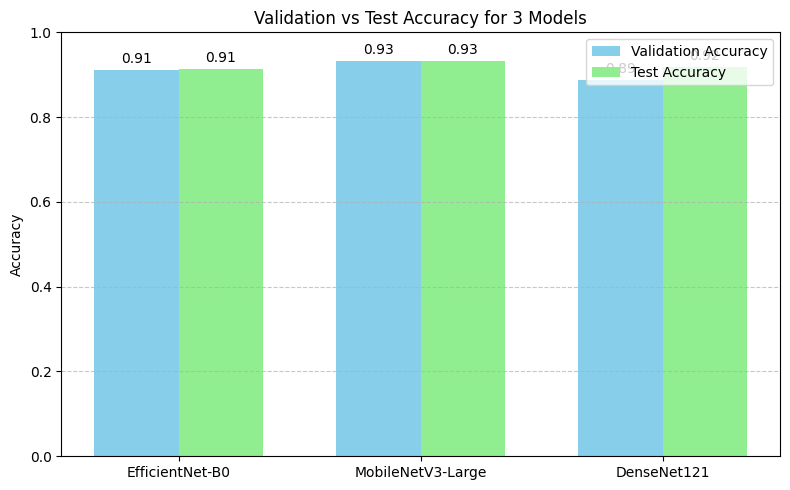

In [25]:
import matplotlib.pyplot as plt
import numpy as np

# Model names
models_list = ["EfficientNet-B0", "MobileNetV3-Large", "DenseNet121"]

# Validation and Test accuracies
val_accs = [best_val_acc_eff, best_val_acc_mob, best_val_acc_dense]
test_accs = [test_acc_eff, test_acc_mob, test_acc_dense]

x = np.arange(len(models_list))  # label locations
width = 0.35  # bar width

fig, ax = plt.subplots(figsize=(8,5))
rects1 = ax.bar(x - width/2, val_accs, width, label='Validation Accuracy', color='skyblue')
rects2 = ax.bar(x + width/2, test_accs, width, label='Test Accuracy', color='lightgreen')

# Add text labels above bars
for rect in rects1 + rects2:
    height = rect.get_height()
    ax.annotate(f'{height:.2f}',
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0,3),  # offset
                textcoords="offset points",
                ha='center', va='bottom', fontsize=10)

# Labels, title, legend
ax.set_ylabel('Accuracy')
ax.set_ylim(0,1.0)
ax.set_title('Validation vs Test Accuracy for 3 Models')
ax.set_xticks(x)
ax.set_xticklabels(models_list)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


# Ensemble of ResNet18 + VGG16

In [26]:
class EnsembleResNetVGG(nn.Module):
    def __init__(self, num_classes=len(class_names), freeze_backbones=False):
        super().__init__()
        # ResNet18 backbone
        res = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        self.resnet_conv = nn.Sequential(*list(res.children())[:-2])  # up to last conv
        self.resnet_gap = nn.AdaptiveAvgPool2d((1,1))  # gives 512
        
        # VGG16 backbone
        vgg = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
        self.vgg_features = vgg.features
        self.vgg_avgpool = vgg.avgpool  # gives (512,7,7) before flatten
        
        # Map flattened VGG features (25088) -> 4096 -> 4096 (match VGG head)
        self.vgg_fc_map = nn.Sequential(
            nn.Linear(25088, 4096),
            nn.ReLU(inplace=False),
            nn.Dropout(0.5),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=False),
        )
        
        # Freeze backbones if requested
        if freeze_backbones:
            for p in self.resnet_conv.parameters():
                p.requires_grad = False
            for p in self.vgg_features.parameters():
                p.requires_grad = False
            for p in self.vgg_fc_map.parameters():
                p.requires_grad = False

        # Fusion head
        self.classifier = nn.Sequential(
            nn.Linear(512 + 4096, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(inplace=False),
            nn.Dropout(0.4),
            nn.Linear(1024, 512),
            nn.ReLU(inplace=False),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )
    def forward(self, x):
        # ResNet branch
        r = self.resnet_conv(x)    # (B,512,7,7)
        r = self.resnet_gap(r)     # (B,512,1,1)
        r = torch.flatten(r, 1)    # (B,512)
        # VGG branch
        v = self.vgg_features(x)   # (B,512,7,7)
        v = self.vgg_avgpool(v)    # (B,512,7,7)
        v = torch.flatten(v, 1)    # (B,25088)
        v = self.vgg_fc_map(v)     # (B,4096)
        # concat
        fused = torch.cat([r, v], dim=1)  # (B,4608)
        out = self.classifier(fused)
        return out

# Create model: NOTE freeze_backbones=False -> allow fine-tuning
model = EnsembleResNetVGG(num_classes=len(class_names), freeze_backbones=False).to(DEVICE)

In [27]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=LR, weight_decay=1e-4)

steps_per_epoch = len(train_loader)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=LR,
    epochs=NUM_EPOCHS,
    steps_per_epoch=steps_per_epoch,
    pct_start=0.1,
    anneal_strategy='cos',
    div_factor=10.0,
    final_div_factor=100.0
)


In [28]:
from torch.cuda.amp import GradScaler, autocast


In [29]:
scaler = GradScaler()

def train_one_epoch(model, loader, optimizer, criterion, scheduler=None):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for imgs, lbls in loader:
        imgs = imgs.to(DEVICE, dtype=torch.float)
        lbls = lbls.to(DEVICE)
        optimizer.zero_grad()
        with torch.amp.autocast('cuda'):
            outputs = model(imgs)
            loss = criterion(outputs, lbls)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        if scheduler is not None:
            # OneCycleLR expects step per batch
            scheduler.step()
        running_loss += loss.item() * imgs.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == lbls).sum().item()
        total += imgs.size(0)
    return running_loss/total, correct/total

def eval_model(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    all_probs = []
    with torch.no_grad():
        for imgs, lbls in loader:
            imgs = imgs.to(DEVICE, dtype=torch.float)
            lbls = lbls.to(DEVICE)
            outputs = model(imgs)
            loss = criterion(outputs, lbls)
            probs = F.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)
            running_loss += loss.item() * imgs.size(0)
            correct += (preds == lbls).sum().item()
            total += imgs.size(0)
            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(lbls.cpu().tolist())
            all_probs.extend(probs.cpu().numpy())
    avg_loss = running_loss/total
    acc = correct/total
    return avg_loss, acc, np.array(all_preds), np.array(all_labels), np.array(all_probs)

# ---------- Training loop ----------
best_val_acc = 0.0
history = {"train_loss":[], "val_loss":[], "train_acc":[], "val_acc":[]}
start_time = time.time()

/tmp/ipykernel_902/653938949.py:1: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


In [30]:
for epoch in range(1, NUM_EPOCHS+1):
    t0 = time.time()
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, scheduler=scheduler)
    val_loss, val_acc, _, _, _ = eval_model(model, val_loader, criterion)
    history["train_loss"].append(train_loss); history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc); history["val_acc"].append(val_acc)
    # OneCycleLR already stepped every batch. Do NOT call scheduler.step(val_acc)
    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_ensemble_model.pth")
        print(f"Epoch {epoch}: saved best model with val_acc={val_acc:.4f}")
    print(f"Epoch {epoch}/{NUM_EPOCHS} | train_loss={train_loss:.4f}, train_acc={train_acc:.4f} | val_loss={val_loss:.4f}, val_acc={val_acc:.4f} | time={time.time()-t0:.1f}s")

print("Training done in", round((time.time()-start_time)/60,2), "minutes. Best val acc:", best_val_acc)


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:227: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


Epoch 1: saved best model with val_acc=0.6269
Epoch 1/10 | train_loss=1.2835, train_acc=0.4334 | val_loss=0.9610, val_acc=0.6269 | time=44.8s
Epoch 2: saved best model with val_acc=0.9744
Epoch 2/10 | train_loss=0.6139, train_acc=0.9106 | val_loss=0.3020, val_acc=0.9744 | time=43.5s
Epoch 3: saved best model with val_acc=0.9830
Epoch 3/10 | train_loss=0.3087, train_acc=0.9796 | val_loss=0.2605, val_acc=0.9830 | time=43.9s
Epoch 4/10 | train_loss=0.2726, train_acc=0.9829 | val_loss=0.2590, val_acc=0.9779 | time=45.2s
Epoch 5/10 | train_loss=0.2524, train_acc=0.9894 | val_loss=0.2690, val_acc=0.9710 | time=42.1s
Epoch 6/10 | train_loss=0.2495, train_acc=0.9883 | val_loss=0.2672, val_acc=0.9761 | time=43.2s
Epoch 7/10 | train_loss=0.2456, train_acc=0.9901 | val_loss=0.2510, val_acc=0.9830 | time=43.8s
Epoch 8/10 | train_loss=0.2405, train_acc=0.9931 | val_loss=0.2489, val_acc=0.9830 | time=43.1s
Epoch 9: saved best model with val_acc=0.9864
Epoch 9/10 | train_loss=0.2395, train_acc=0.9916

In [31]:
#NUM_EPOCHS = 10

In [32]:
model.load_state_dict(torch.load("best_ensemble_model.pth", map_location=DEVICE))
test_loss, test_acc, preds, labels, probs = eval_model(model, test_loader, criterion)
print("Test loss:", test_loss, "Test acc:", test_acc)

Test loss: 0.22991778757296452 Test acc: 0.9948979591836735


In [33]:
model.load_state_dict(torch.load("best_ensemble_model.pth", map_location=DEVICE))
test_loss, test_acc, preds, labels_gt, probs = eval_model(model, test_loader, criterion)
print("\nTEST -> loss:", test_loss, "acc:", test_acc)
print("\nClassification Report:")
print(classification_report(labels_gt, preds, target_names=class_names, digits=4))



TEST -> loss: 0.22991778757296452 acc: 0.9948979591836735

Classification Report:
                         precision    recall  f1-score   support

                 Benign     0.9932    0.9864    0.9898       147
      [Malignant] Pre-B     1.0000    1.0000    1.0000       147
      [Malignant] Pro-B     1.0000    1.0000    1.0000       147
[Malignant] early Pre-B     0.9865    0.9932    0.9898       147

               accuracy                         0.9949       588
              macro avg     0.9949    0.9949    0.9949       588
           weighted avg     0.9949    0.9949    0.9949       588



Confusion Matrix:
 [[145   0   0   2]
 [  0 147   0   0]
 [  0   0 147   0]
 [  1   0   0 146]]


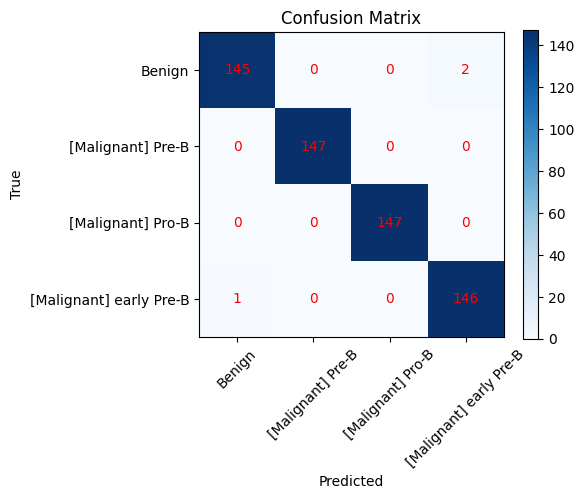

In [34]:
cm = confusion_matrix(labels_gt, preds)
print("Confusion Matrix:\n", cm)

plt.figure(figsize=(6,5))
plt.imshow(cm, cmap='Blues')
plt.title("Confusion Matrix")
plt.colorbar()

plt.xticks(range(len(class_names)), class_names, rotation=45)
plt.yticks(range(len(class_names)), class_names)
plt.xlabel("Predicted")
plt.ylabel("True")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i,j]), ha='center', va='center', color='red')

plt.tight_layout()
plt.show()

In [35]:
def replace_relu(model):
    for name, module in model.named_children():
        if isinstance(module, nn.ReLU) and module.inplace:
            setattr(model, name, nn.ReLU(inplace=False))
        else:
            replace_relu(module)

replace_relu(model)
model.to(DEVICE)
model.eval()

EnsembleResNetVGG(
  (resnet_conv): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU()
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (

# Explainable AI (Guided Backpropagation)*

In [36]:
class GuidedBackprop:
    def __init__(self, model):
        self.model = model
        self.model.eval()
        self.handles = []
        self._register_hooks()

    def _relu_backward_hook(self, module, grad_in, grad_out):
        if isinstance(grad_in, tuple):
            modified = tuple(
                (g.clone().clamp(min=0.0) if isinstance(g, torch.Tensor) else g)
                for g in grad_in
            )
            return modified
        return grad_in

    def _register_hooks(self):
        for module in self.model.modules():
            if isinstance(module, nn.ReLU):
                handle = module.register_full_backward_hook(self._relu_backward_hook)
                self.handles.append(handle)

    def generate(self, input_tensor, target_class):
        input_tensor = input_tensor.to(DEVICE)
        input_tensor.requires_grad = True

        outputs = self.model(input_tensor)
        self.model.zero_grad()

        loss = outputs[0, target_class]
        loss.backward()

        grad = input_tensor.grad.detach().cpu().numpy()[0]
        return grad

    def remove(self):
        for h in self.handles:
            h.remove()
        self.handles = []

gb = GuidedBackprop(model)

In [37]:
sample_imgs = []
sample_labels = []
for i in range(5):
    img, lbl = test_ds[i]
    sample_imgs.append(img.unsqueeze(0))
    sample_labels.append(lbl)

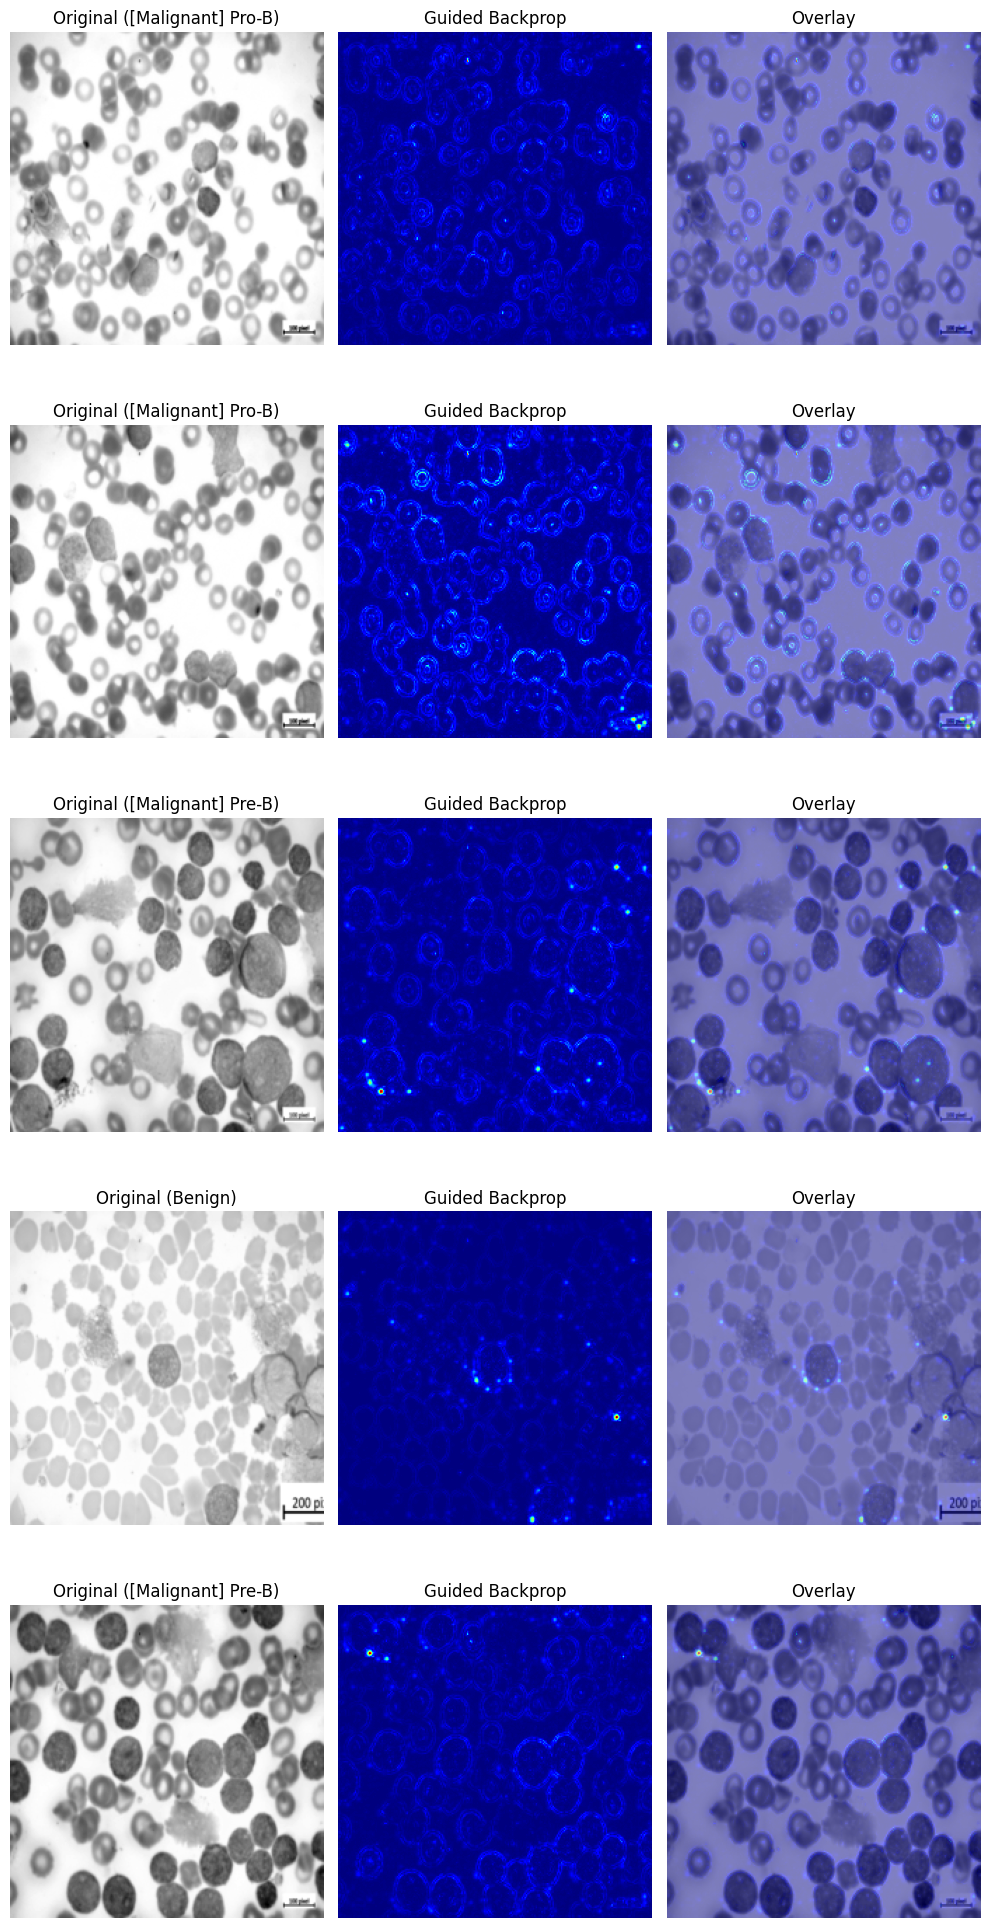

In [38]:
IM_MEAN = np.array([0.485, 0.456, 0.406]).reshape(1,1,3)
IM_STD  = np.array([0.229, 0.224, 0.225]).reshape(1,1,3)

# ---------------------- Visualization ----------------------
fig, axes = plt.subplots(len(sample_imgs), 3, figsize=(10, 4*len(sample_imgs)))

for i, (img_t, lbl) in enumerate(zip(sample_imgs, sample_labels)):
    grad = gb.generate(img_t, int(lbl))

    sal = np.mean(np.abs(grad), axis=0)
    sal = (sal - sal.min()) / (sal.max() - sal.min() + 1e-8)

    orig = img_t[0].cpu().numpy().transpose(1,2,0)
    orig = (orig * IM_STD) + IM_MEAN  # FIXED correct denormalization
    orig = np.clip(orig, 0, 1)
    orig_gray = orig[:,:,0]

    axes[i,0].imshow(orig_gray, cmap='gray')
    axes[i,0].set_title(f"Original ({class_names[int(lbl)]})")
    axes[i,0].axis('off')

    axes[i,1].imshow(sal, cmap='jet')
    axes[i,1].set_title("Guided Backprop")
    axes[i,1].axis('off')

    axes[i,2].imshow(orig_gray, cmap='gray')
    axes[i,2].imshow(sal, cmap='jet', alpha=0.5)
    axes[i,2].set_title("Overlay")
    axes[i,2].axis('off')

plt.tight_layout()
plt.show()

In [39]:
torch.save(model.state_dict(), "ensemble_resnet18_vgg16_oversample_guidedbp.pth")
print("Saved model: ensemble_resnet18_vgg16_oversample_guidedbp.pth")

# ---------------------- Summary ----------------------
print("\n--- Summary ---")
print("Classes:", class_names)
print("Train samples:", len(train_idx), "Val:", len(val_idx), "Test:", len(test_idx))
print("Best validation acc:", best_val_acc)
print("Final test acc:", test_acc)
print("ok, Done")


Saved model: ensemble_resnet18_vgg16_oversample_guidedbp.pth

--- Summary ---
Classes: ['Benign', '[Malignant] Pre-B', '[Malignant] Pro-B', '[Malignant] early Pre-B']
Train samples: 2741 Val: 587 Test: 588
Best validation acc: 0.9863713798977853
Final test acc: 0.9948979591836735
ok, Done
